# EL F1 Score Matrices

Reads `scores.csv` and shows heatmaps with **models as rows**, **configs as columns**, and F1 scores as values — one heatmap per KB metric (Wikidata, GeoNames, NIL).

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

SCORES_CSV = Path("el-evaluation/scores.csv")

df = pd.read_csv(SCORES_CSV)

# Drop the bogus duplicate row (all metrics = 1.0)
df = df.drop_duplicates(subset=["source_text", "model", "temperature", "think"], keep="first")

# Create a readable config label
def make_config(row):
    parts = []
    if row["temperature"] == row["temperature"]:  # not NaN
        parts.append(f"temp={row['temperature']}")
    think = str(row.get("think", "")).strip().lower()
    if think and think not in ("", "nan"):
        parts.append(f"think={think}")
    return "  ".join(parts) if parts else "default"

df["config"] = df.apply(make_config, axis=1)

print(f"Loaded {len(df)} runs from {SCORES_CSV.name}")
print(f"Sources: {df['source_text'].unique()}")
print(f"Models:  {df['model'].unique()}")
print(f"Configs: {df['config'].unique()}")
df[["source_text", "model", "config", "wd_f1", "gn_f1", "nil_f1"]]

Loaded 9 runs from scores.csv
Sources: ['1816_el_gs' '1816_third_letter']
Models:  ['cogito-2.1:671b' 'deepseek-v4-flash' 'deepseek-v4-pro' 'gemma4:31b'
 'glm-5.1' 'kimi-k2.7-code' 'mistral-large-3:675b' 'qwen3.5:397b']
Configs: ['temp=0.0  think=false']


,source_text,model,config,wd_f1,gn_f1,nil_f1
0,1816_el_gs,cogito-2.1:671b,temp=0.0 think=false,0.0000,0.0000,0.5931
1,1816_el_gs,deepseek-v4-flash,temp=0.0 think=false,0.6442,0.2429,0.6774
2,1816_el_gs,deepseek-v4-pro,temp=0.0 think=false,0.6729,0.2740,0.4912
3,1816_el_gs,gemma4:31b,temp=0.0 think=false,0.7640,0.4000,0.8408
4,1816_el_gs,glm-5.1,temp=0.0 think=false,0.6696,0.2458,0.3711
5,1816_el_gs,kimi-k2.7-code,temp=0.0 think=false,0.6126,0.2597,0.3960
6,1816_el_gs,mistral-large-3:675b,temp=0.0 think=false,0.6311,0.2676,0.5042
7,1816_el_gs,qwen3.5:397b,temp=0.0 think=false,0.6989,0.3617,0.7417
8,1816_third_letter,gemma4:31b,temp=0.0 think=false,0.7000,0.3540,0.9223


In [2]:
# --- Run Tracker ---
# Scans el-results/ for completed _el.spacy files and shows a completion matrix.

EL_RESULTS = Path("el-results")
SOURCE = "1816_el_gs"

MODELS = ["deepseek-v4-flash", "gemma4:31b", "kimi-k2.7-code"]

CONFIGS = [
    ("false", 0.0),
    ("false", 0.5),
    ("false", 1.0),
    ("low", 1.0),
    ("medium", 1.0),
    ("high", 1.0),
]

rows = []
for model in MODELS:
    row = {"Model": model}
    for think, temp in CONFIGS:
        slug = model.replace(":", "-").replace("/", "-")
        think_part = f"think{think}" if think and think.lower() not in ("false", "") else "thinkfalse"
        filename = f"{SOURCE}__{slug}_t{temp}_{think_part}_el.spacy"
        col = f"think={think}  temp={temp}"
        row[col] = "✅" if (EL_RESULTS / filename).exists() else "❌"
    rows.append(row)

tracker = pd.DataFrame(rows).set_index("Model")
tracker["✅ Completed"] = (tracker.values == "✅").sum(axis=1)
tracker["❌ Remaining"] = (tracker.values == "❌").sum(axis=1)

print(f"Scanning: {EL_RESULTS.resolve()}")
print(f"Total combos: {len(MODELS)} models × {len(CONFIGS)} configs = {len(MODELS) * len(CONFIGS)}\n")
tracker

# For saving the plots
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

def save_fig(fig, name):
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"saved {path}")

Scanning: /home/tijn-do/github/hist-dutch-travelogues-nlp/entity_linking/el-results
Total combos: 3 models × 6 configs = 18



In [3]:
def plot_f1_heatmap(data, metric_col, metric_label, source_filter=None, vmin=0, vmax=1):
    """Plot a heatmap with models as rows, configs as columns, F1 as values."""
    plot_df = data.copy()
    if source_filter:
        plot_df = plot_df[plot_df["source_text"] == source_filter].copy()

    pivot = plot_df.pivot_table(
        index="model", columns="config", values=metric_col, aggfunc="first"
    )

    fig, ax = plt.subplots(figsize=(max(2.5, len(pivot.columns) * 1.5), len(pivot.index) * 0.8 + 1))
    sns.heatmap(
        pivot, annot=True, fmt=".3f", cmap="YlGnBu",
        vmin=vmin, vmax=vmax, linewidths=0.5,
        cbar_kws={"label": f"{metric_label} F₁"},
        ax=ax,
    )
    ax.set_title(f"{metric_label} EL F1", fontsize=13, fontweight="bold")
    ax.set_ylabel("")
    ax.set_xlabel("")
    plt.yticks(rotation=0)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    
    # Sanitize label into a filename-safe slug (e.g. "NIL (Wikidata)" -> "NIL_Wikidata")
    file_slug = metric_label.replace(" ", "_").replace("(", "").replace(")", "")
    save_fig(fig, f"{file_slug}_f1")

    plt.show()

    # Also print the raw numbers
    print(f"\n{metric_label} F₁  ({source_filter or 'all sources'}):")
    display(pivot.round(4))

## Wikidata F₁

/tmp/ipykernel_21064/3768365633.py:23: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


saved figures/Wikidata_f1.png


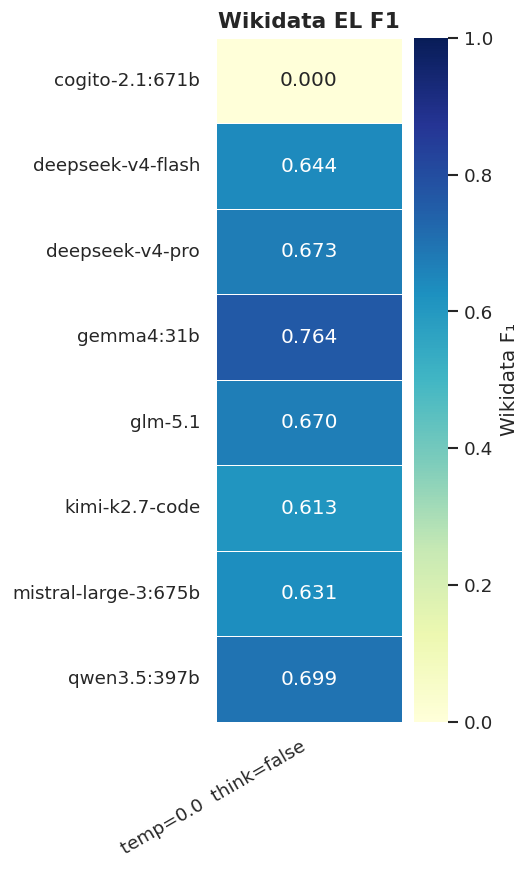


Wikidata F₁  (1816_el_gs):


config,temp=0.0 think=false
model,
cogito-2.1:671b,0.0000
deepseek-v4-flash,0.6442
deepseek-v4-pro,0.6729
gemma4:31b,0.7640
glm-5.1,0.6696
kimi-k2.7-code,0.6126
mistral-large-3:675b,0.6311
qwen3.5:397b,0.6989


In [4]:
plot_f1_heatmap(df, "wd_f1", "Wikidata", source_filter="1816_el_gs")


## GeoNames F₁

/tmp/ipykernel_21064/3768365633.py:23: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


saved figures/GeoNames_f1.png


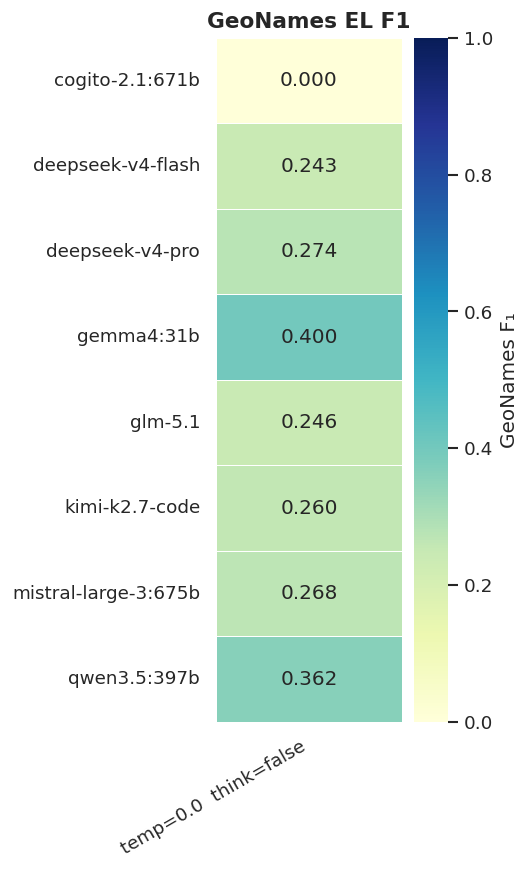


GeoNames F₁  (1816_el_gs):


config,temp=0.0 think=false
model,
cogito-2.1:671b,0.0000
deepseek-v4-flash,0.2429
deepseek-v4-pro,0.2740
gemma4:31b,0.4000
glm-5.1,0.2458
kimi-k2.7-code,0.2597
mistral-large-3:675b,0.2676
qwen3.5:397b,0.3617


In [5]:
plot_f1_heatmap(df, "gn_f1", "GeoNames", source_filter="1816_el_gs")

## NIL F₁ (Wikidata)

Wikidata-scoped NIL F₁ (`nil_wd_f1`): abstention from a Wikidata QID specifically, as opposed to the combined NIL (abstention from both KBs) shown elsewhere.


/tmp/ipykernel_21064/3768365633.py:23: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


saved figures/NIL_Wikidata_f1.png


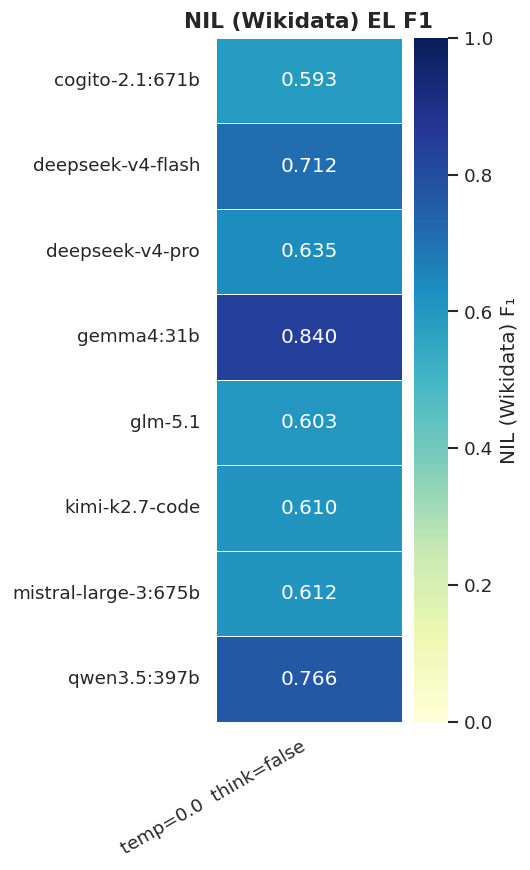


NIL (Wikidata) F₁  (1816_el_gs):


config,temp=0.0 think=false
model,
cogito-2.1:671b,0.5931
deepseek-v4-flash,0.7121
deepseek-v4-pro,0.6349
gemma4:31b,0.8395
glm-5.1,0.6034
kimi-k2.7-code,0.6102
mistral-large-3:675b,0.6119
qwen3.5:397b,0.7662


In [6]:
plot_f1_heatmap(df, "nil_wd_f1", "NIL (Wikidata)", source_filter="1816_el_gs")


## Additional analysis

**Metric level note.** The `wd_*`/`gn_*`/`combined_*` columns in `scores.csv` are interpreted by `source_text`:
- `1816_el_gs` — EL ran on **gold-standard entities** (no NER misses), so these are **EL-only** linking metrics. All current runs are this source.
- `1816_third_letter` — EL ran on **NER-predicted entities**, so these are **end-to-end** (NER + linking) metrics.

`nil_*` is always EL-only by construction. Figure subtitles state the level.

In [7]:
from pathlib import Path
import numpy as np

MODEL_COLORS = {
    "deepseek-v4-flash": "#0b6aae",
    "deepseek-v4-pro": "#287f8c",
    "gemma4:31b": "#af200d",
    "glm-5.1": "#e07b39",
    "kimi-k2.7-code": "#842cbe",
    "mistral-large-3:675b": "#2e8b57",
    "qwen3.5:397b": "#b8860b",
    "cogito-2.1:671b": "#d81b60",
}
THINK_MARKERS = {"false": "o", "low": "^", "medium": "s", "high": "D"}
THINK_ORDER = ["false", "low", "medium", "high"]
TEMP_ORDER = [0.0, 0.5, 1.0]

# Ordered categoricals for consistent plotting
df["think"] = pd.Categorical(df["think"].astype(str).str.lower(), categories=THINK_ORDER, ordered=True)
df["temperature"] = pd.Categorical(df["temperature"], categories=TEMP_ORDER, ordered=True)
df["duration_min"] = df["duration_seconds"] / 60.0

def level_label(src):
    return "EL-only (gold entities)" if src == "1816_el_gs" else "end-to-end (NER+EL)"

SOURCE_LEVEL = level_label(df["source_text"].iloc[0]) if len(df) else "?"

METRICS = [("wd_p", "Precision"), ("wd_r", "Recall"), ("wd_f1", "F1")]
print(f"Source level: {SOURCE_LEVEL}")

Source level: EL-only (gold entities)


### F1 vs inference time

Wikidata F1 (`wd_f1`) against EL pipeline runtime, colored by model, marker by thinking mode. The dashed line marks the Pareto (efficiency) frontier - runs not dominated by any other on both higher F1 and lower time.

saved figures/f1_vs_inference.png


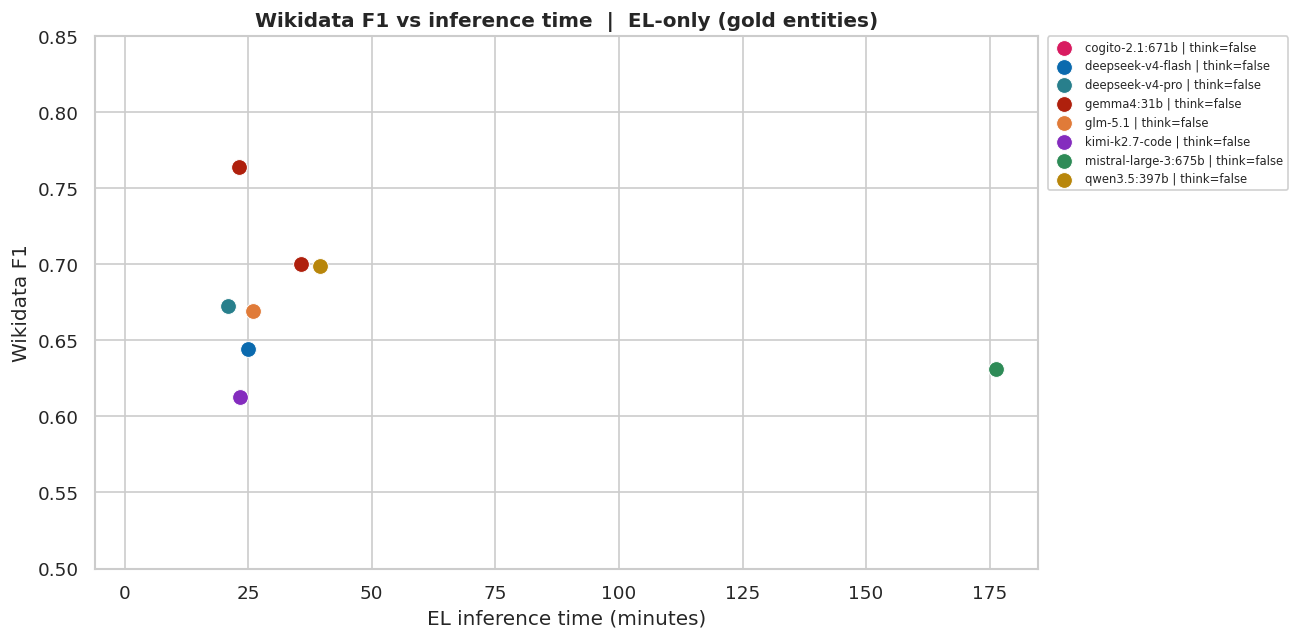

In [8]:
fig, ax = plt.subplots(figsize=(11, 5.5))  # wider to accommodate outside legend
for model in df["model"].unique():
    sub = df[df["model"] == model]
    for think in THINK_ORDER:
        s = sub[sub["think"] == think]
        if s.empty:
            continue
        ax.scatter(s["duration_min"], s["wd_f1"],
                   c=MODEL_COLORS[model], marker=THINK_MARKERS[think],
                   s=90, edgecolor="white", linewidth=0.6,  # white edge pops better
                   label=f"{model} | think={think}", zorder=3)

ax.set_xlabel("EL inference time (minutes)")
ax.set_ylabel("Wikidata F1")
ax.set_title(f"Wikidata F1 vs inference time  |  {SOURCE_LEVEL}", fontweight="bold")
ax.set_ylim(0.5, 0.85)

# Legend outside the plot, anchored to the right of the axes
legend = ax.legend(
    fontsize=7,
    ncol=1,                          # single column works better outside
    loc="upper left",
    bbox_to_anchor=(1.01, 1),        # just right of the axes
    borderaxespad=0,
    framealpha=0.9,
    edgecolor="#ccc",
)

plt.tight_layout()
save_fig(fig, "f1_vs_inference")
plt.show()

### Precision vs Recall

Each run as Wikidata precision (y) vs recall (x). Dashed contours are iso-F1 lines. Shows whether a config's gains come from precision or recall.

saved figures/precision_vs_recall.png


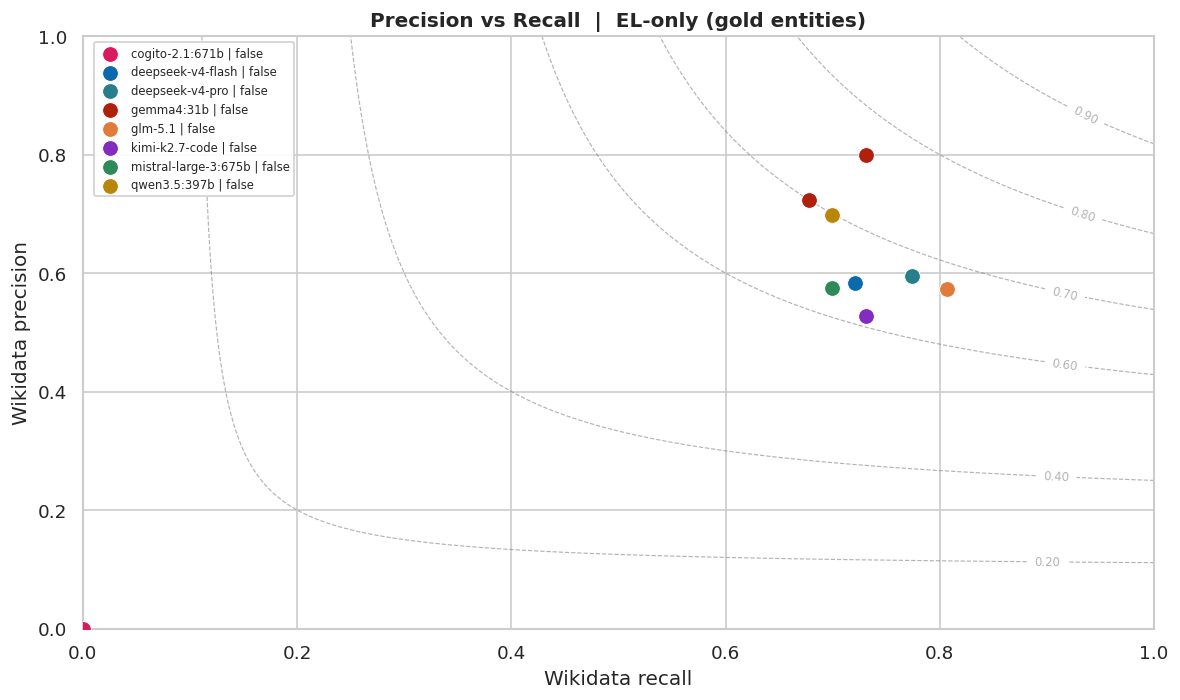

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))  # wider for the outside legend

# iso-F1 contours
p_grid, r_grid = np.meshgrid(np.linspace(0.01, 1, 120), np.linspace(0.01, 1, 120))
f1_grid = 2 * p_grid * r_grid / (p_grid + r_grid)
cs = ax.contour(r_grid, p_grid, f1_grid, levels=[0.2, 0.4, 0.6, 0.7, 0.8, 0.9],
                colors="grey", linewidths=0.7, linestyles="--", alpha=0.6)
ax.clabel(cs, inline=True, fontsize=7, fmt="%.2f")

for model in df["model"].unique():
    sub = df[df["model"] == model]
    for think in THINK_ORDER:
        s = sub[sub["think"] == think]
        if s.empty:
            continue
        ax.scatter(s["wd_r"], s["wd_p"], c=MODEL_COLORS[model],
                   marker=THINK_MARKERS[think], s=90, edgecolor="white",
                   linewidth=0.6, label=f"{model} | {think}", zorder=3)

ax.set_xlabel("Wikidata recall")
ax.set_ylabel("Wikidata precision")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title(f"Precision vs Recall  |  {SOURCE_LEVEL}", fontweight="bold")

ax.legend(
    fontsize=7,
    ncol=1,
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
    bbox_transform=ax.transAxes,
    borderaxespad=0,
    framealpha=0.9,
    edgecolor="#ccc",
)

plt.tight_layout()
save_fig(fig, "precision_vs_recall")
plt.show()

### Precision vs Recall — NIL (Wikidata)

Same idea as the Wikidata linking plot above, but for **NIL abstention from a Wikidata QID**: each run as NIL-Wikidata precision (y) vs recall (x), with iso-F1 contours. Shows whether a config's NIL-Wikidata gains come from precision or recall.


saved figures/nil_wd_precision_vs_recall.png


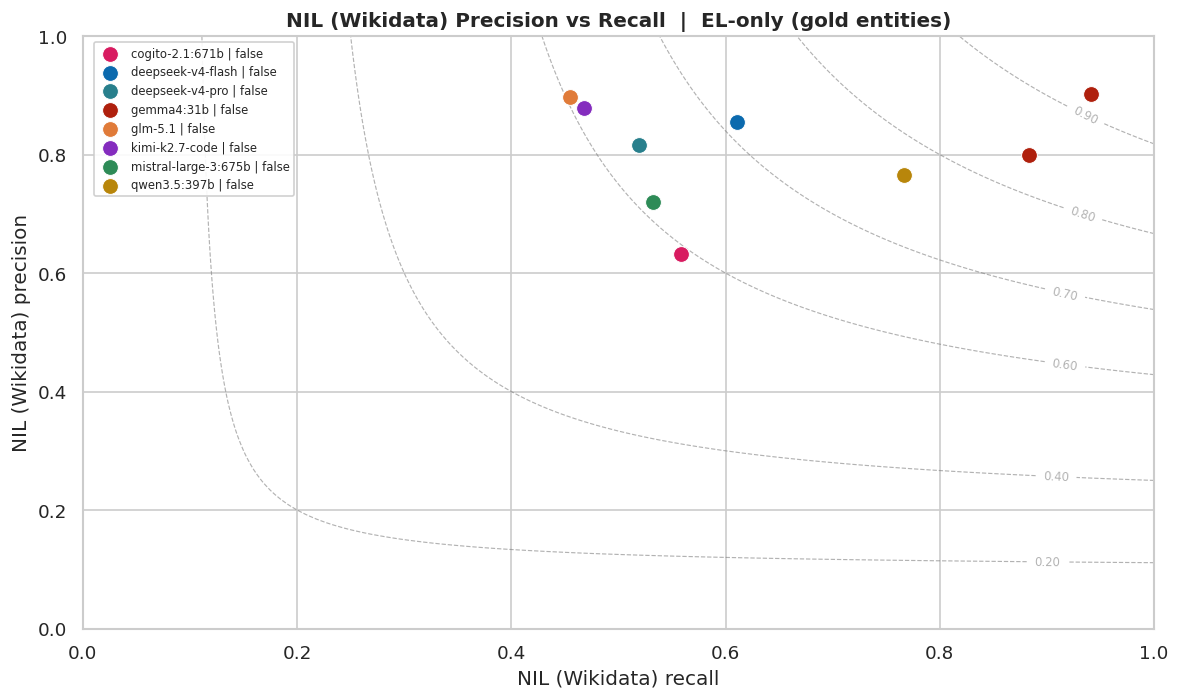

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))  # wider for the outside legend

# iso-F1 contours (same grid as the Wikidata plot)
p_grid, r_grid = np.meshgrid(np.linspace(0.01, 1, 120), np.linspace(0.01, 1, 120))
f1_grid = 2 * p_grid * r_grid / (p_grid + r_grid)
cs = ax.contour(r_grid, p_grid, f1_grid, levels=[0.2, 0.4, 0.6, 0.7, 0.8, 0.9],
                colors="grey", linewidths=0.7, linestyles="--", alpha=0.6)
ax.clabel(cs, inline=True, fontsize=7, fmt="%.2f")

for model in df["model"].unique():
    sub = df[df["model"] == model]
    for think in THINK_ORDER:
        s = sub[sub["think"] == think]
        if s.empty:
            continue
        ax.scatter(s["nil_wd_r"], s["nil_wd_p"], c=MODEL_COLORS[model],
                   marker=THINK_MARKERS[think], s=90, edgecolor="white",
                   linewidth=0.6, label=f"{model} | {think}", zorder=3)

ax.set_xlabel("NIL (Wikidata) recall")
ax.set_ylabel("NIL (Wikidata) precision")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title(f"NIL (Wikidata) Precision vs Recall  |  {SOURCE_LEVEL}", fontweight="bold")

ax.legend(
    fontsize=7,
    ncol=1,
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
    bbox_transform=ax.transAxes,
    borderaxespad=0,
    framealpha=0.9,
    edgecolor="#ccc",
)

plt.tight_layout()
save_fig(fig, "nil_wd_precision_vs_recall")
plt.show()

### Summary table

Best Wikidata-F1 config per model, with runtime and F1-per-minute efficiency, plus the overall best.

In [11]:
df["wd_f1_per_min"] = df["wd_f1"] / df["duration_min"]
rows = []
for model in df["model"].unique():
    sub = df[df["model"] == model]
    best = sub.loc[sub["wd_f1"].idxmax()]
    rows.append({
        "model": model,
        "best_config": best["config"],
        "wd_p": round(best["wd_p"], 4),
        "wd_r": round(best["wd_r"], 4),
        "wd_f1": round(best["wd_f1"], 4),
        "duration_min": round(best["duration_min"], 1),
        "wd_f1_per_min": round(best["wd_f1_per_min"], 5),
    })
summary = pd.DataFrame(rows).sort_values("wd_f1", ascending=False)
overall = df.loc[df["wd_f1"].idxmax()]
eff_row = df.loc[df["wd_f1_per_min"].idxmax()]
print(f"Overall best Wikidata F1: {overall['model']} / {overall['config']} = {overall['wd_f1']:.4f}")
print(f"Most efficient (F1/min):  {eff_row['model']} / {eff_row['config']} = {eff_row['wd_f1_per_min']:.5f}")
display(summary)

Overall best Wikidata F1: gemma4:31b / temp=0.0  think=false = 0.7640
Most efficient (F1/min):  gemma4:31b / temp=0.0  think=false = 0.03303


,model,best_config,wd_p,wd_r,wd_f1,duration_min,wd_f1_per_min
3,gemma4:31b,temp=0.0 think=false,0.8000,0.7312,0.7640,23.1,0.03303
7,qwen3.5:397b,temp=0.0 think=false,0.6989,0.6989,0.6989,39.5,0.01769
2,deepseek-v4-pro,temp=0.0 think=false,0.5950,0.7742,0.6729,21.0,0.03210
4,glm-5.1,temp=0.0 think=false,0.5725,0.8065,0.6696,26.0,0.02576
1,deepseek-v4-flash,temp=0.0 think=false,0.5826,0.7204,0.6442,25.0,0.02575
6,mistral-large-3:675b,temp=0.0 think=false,0.5752,0.6989,0.6311,176.2,0.00358
5,kimi-k2.7-code,temp=0.0 think=false,0.5271,0.7312,0.6126,23.4,0.02616
0,cogito-2.1:671b,temp=0.0 think=false,0.0000,0.0000,0.0000,2.6,0.00000


### Gold standard KB-ID coverage (toponyms)

Pie chart of KB-ID coverage for the **toponym entities the EL module actually links** — `E53_Place` and `E18_Physical_Thing` — drawn from the entity-linking gold standard (`ner/gs_annotations/gs_el_gold_template.csv`). Slices are mutually exclusive: a toponym can have both a Wikidata QID and a GeoNames ID, only one, or neither (NIL). Non-geographical entity types (vehicles, time-spans, expressions, physical/biological objects, documents) are excluded from EL by design, so they are filtered out before counting.

saved figures/gold_kb_id_coverage.png


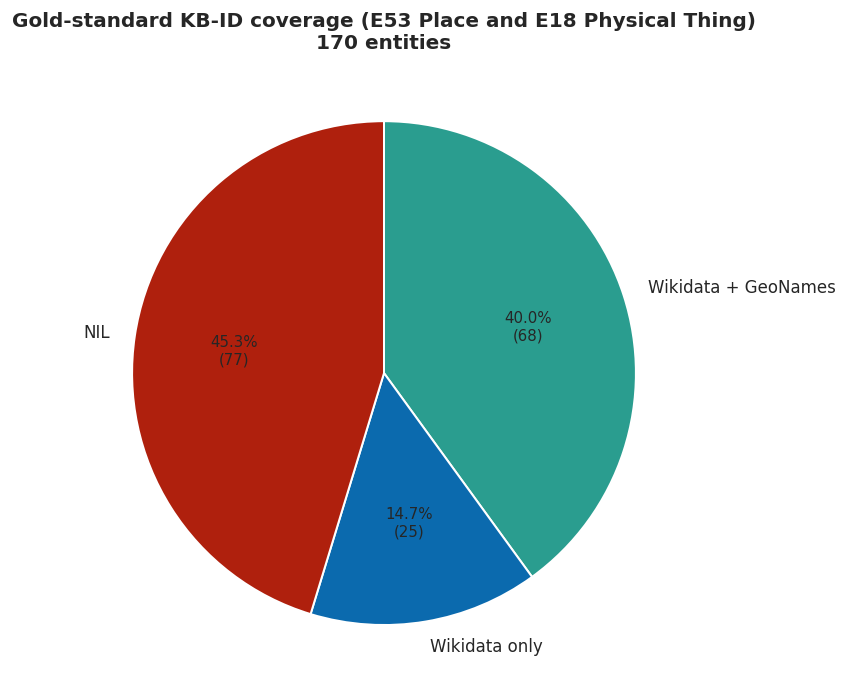


170 toponyms (E53_Place, E18_Physical_Thing):
  Wikidata + GeoNames                68  (40.0%)
  Wikidata only                      25  (14.7%)
  NIL                                77  (45.3%)


In [12]:
import pandas as pd

# Gold CSV lives at the project root; this notebook runs from entity_linking/
GOLD_CSV = Path("../ner/gs_annotations/gs_el_gold_template.csv")
gs = pd.read_csv(GOLD_CSV)

# EL only runs on toponyms: E53_Place and E18_Physical_Thing
TOPO_LABELS = ["E53_Place", "E18_Physical_Thing"]
topo = gs[gs["label"].isin(TOPO_LABELS)].copy()

# "Has a KB ID" = non-empty AND not the explicit NIL marker (blank cells are
# also treated as NIL / unannotated)
def has_id(col):
    v = col.fillna("").astype(str).str.strip().str.upper()
    return (v != "") & (v != "NAN") & (v != "NIL")

has_wd = has_id(topo["wikidata_qid"])
has_gn = has_id(topo["geonames_id"])

slices = {
    "Wikidata + GeoNames": (has_wd & has_gn).sum(),
    "Wikidata only": (has_wd & ~has_gn).sum(),
    "GeoNames ID only": (~has_wd & has_gn).sum(),
    "NIL": (~has_wd & ~has_gn).sum(),
}
slices = {k: int(v) for k, v in slices.items() if v > 0}  # drop empty slices
total = sum(slices.values())

colors = ["#2a9d8f", "#0b6aae", "#af200d", "#e9c46a"]
fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    slices.values(),
    labels=slices.keys(),
    autopct=lambda p: f"{p:.1f}%\n({int(round(p * total / 100))})",
    colors=colors[: len(slices)],
    startangle=90,
    counterclock=False,
    wedgeprops=dict(edgecolor="white", linewidth=1.2),
    textprops=dict(fontsize=10),
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title(
    f"Gold-standard KB-ID coverage (E53 Place and E18 Physical Thing)\n{total} entities",
    fontweight="bold", fontsize=12,
)
plt.tight_layout()
save_fig(fig, "gold_kb_id_coverage")
plt.show()

print(f"\n{total} toponyms ({', '.join(TOPO_LABELS)}):")
for k, v in slices.items():
    print(f"  {k:32s} {v:4d}  ({v/total:.1%})")